# 06 — Analyst reporting, and embedding-based anomaly detection

Two lighter-weight Phase 2 capabilities, demonstrated together since neither needs a long
training run:

1. **`reporting.py`** — turns `pipeline.PipelineResult`'s alert/event tables into a
   Seaborn report-card figure and a Plotly interactive dashboard, for a shift-handoff
   briefing or a live monitoring view.
2. **`anomaly.py`** — a nearest-neighbor embedding distance (via a HOG embedder here, no
   model download required) that flags imagery unlike anything in a reference gallery of
   "normal" corridor scenes, independent of the four-class detector taxonomy.

Requires the `dataviz` and `anomaly` extras: `pip install -e ".[dataviz,anomaly]"`.

In [1]:
from pathlib import Path
import sys
HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

Project root: C:\dev\infrastructure-overwatch


## Part 1 — Reporting, from a real (if quick) pipeline run

In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader

from infrastructure_overwatch.synthetic import GRID, IMG_SIZE, N_SYNTHETIC_CLASSES, PROTECTED_ZONE, SYNTHETIC_CLASS_NAMES, SyntheticCorridorDataset, render_corridor_sequence
from infrastructure_overwatch.detectors.grid_cnn import GridDetector, GridCNNAdapter, train_grid_detector
from infrastructure_overwatch.calibration import ConfidenceCalibrator, DEFAULT_TRIAGE_THRESHOLDS
from infrastructure_overwatch.tracking import MultiTracker
from infrastructure_overwatch.events import PipelineEventEngine
from infrastructure_overwatch.pipeline import run_frame_sequence

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# A quick detector -- this notebook is about reporting, not detector accuracy.
day_train_ds = SyntheticCorridorDataset(400, domain="day", seed=1)
loader = DataLoader(day_train_ds, batch_size=32, shuffle=True)
model = GridDetector(n_classes=N_SYNTHETIC_CLASSES, grid_h=GRID, grid_w=GRID)
train_grid_detector(model, loader, epochs=15, device=device, quiet=True)
adapter = GridCNNAdapter(model, class_names=SYNTHETIC_CLASS_NAMES, img_w=IMG_SIZE, img_h=IMG_SIZE, thresh=0.4, device=device)
print("Trained a quick detector for this notebook's demo run.")

Trained a quick detector for this notebook's demo run.


In [3]:
rng = np.random.default_rng(11)
sequence = render_corridor_sequence(100, rng, domain="night", n_threats=2)
frames = [np.transpose(img, (2, 0, 1)).mean(axis=0, keepdims=True).astype("float32") for img, _boxes, _ids in sequence]

result = run_frame_sequence(
    frames=frames, detector=adapter, protected_zone=PROTECTED_ZONE, fps=10.0,
    tracker=MultiTracker(), event_engine=PipelineEventEngine(protected_zone=PROTECTED_ZONE),
    calibrator=None, triage_thresholds=DEFAULT_TRIAGE_THRESHOLDS,
)
alerts_df = result.alerts_frame()
events_df = result.events_frame()
print(f"{len(alerts_df)} detections, {len(events_df)} events")

2419 detections, 81 events


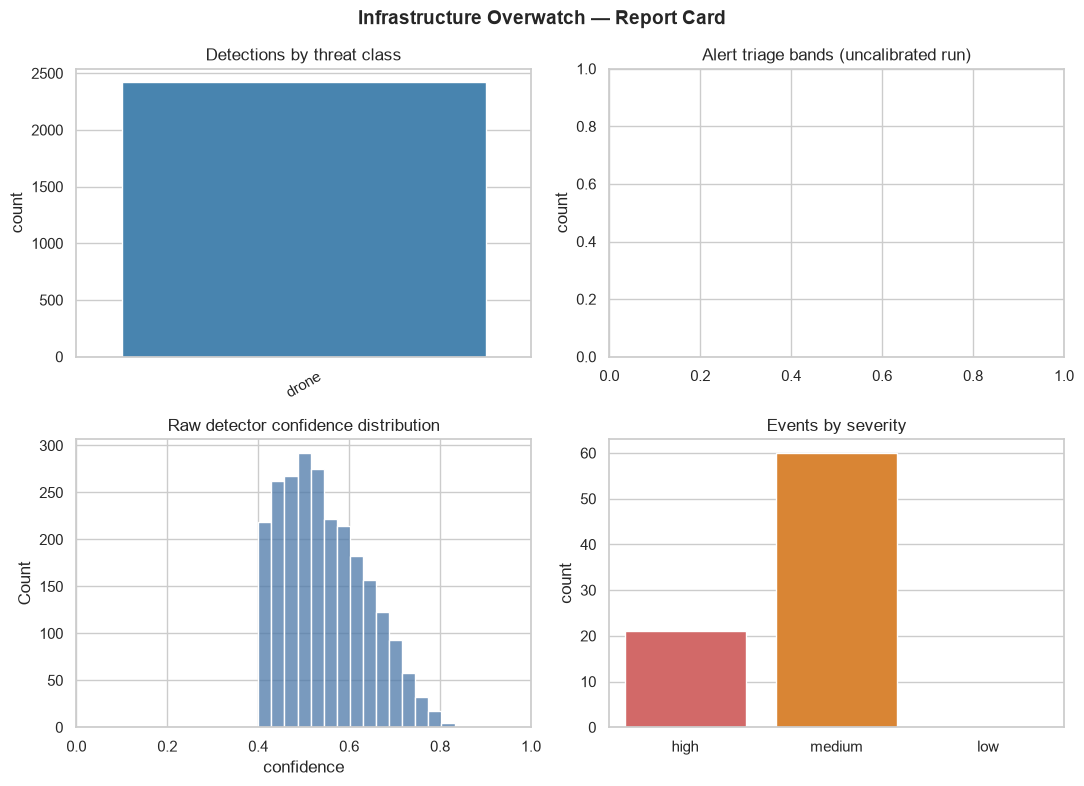

Wrote outputs/notebook06_report_card.png and outputs/notebook06_dashboard.html


In [4]:
from infrastructure_overwatch.reporting import build_report_card, build_dashboard

fig = build_report_card(alerts_df, events_df, out_path="../outputs/notebook06_report_card.png")
import matplotlib.pyplot as plt
plt.show()

dash = build_dashboard(alerts_df, events_df, out_path="../outputs/notebook06_dashboard.html")
print("Wrote outputs/notebook06_report_card.png and outputs/notebook06_dashboard.html")

## Part 2 — Embedding-based anomaly detection

Fit a reference gallery from Day-domain corridor renders (the "normal" case), then score
Day imagery (should look familiar) against Night imagery (a genuinely different visual
domain) to see the anomaly-distance mechanism actually separate them.

In [5]:
from infrastructure_overwatch.anomaly import EmbeddingAnomalyScorer, HOGEmbedder
from infrastructure_overwatch.synthetic import random_threats, render_day, render_night

def render_uint8(render_fn, seed):
    rng = np.random.default_rng(seed)
    threats = random_threats(rng)
    img, _boxes = render_fn(threats, rng)
    return (np.clip(img, 0, 1) * 255).astype(np.uint8)

gallery_images = [render_uint8(render_day, seed) for seed in range(1, 31)]
day_val_images = [render_uint8(render_day, seed) for seed in range(100, 110)]
night_val_images = [render_uint8(render_night, seed) for seed in range(100, 110)]

scorer = EmbeddingAnomalyScorer(HOGEmbedder(size=(96, 96))).fit(gallery_images)
threshold = scorer.calibrate_threshold([render_uint8(render_day, seed) for seed in range(200, 220)], percentile=95.0)
print(f"Calibrated threshold (95th percentile of held-out Day scores): {threshold:.4f}")

day_scores = [s.score for s in scorer.score(day_val_images)]
night_scores = [s.score for s in scorer.score(night_val_images)]
print(f"Day   val anomaly score: mean {np.mean(day_scores):.4f}")
print(f"Night val anomaly score: mean {np.mean(night_scores):.4f}")

Calibrated threshold (95th percentile of held-out Day scores): 0.4291
Day   val anomaly score: mean 0.3635
Night val anomaly score: mean 0.4728


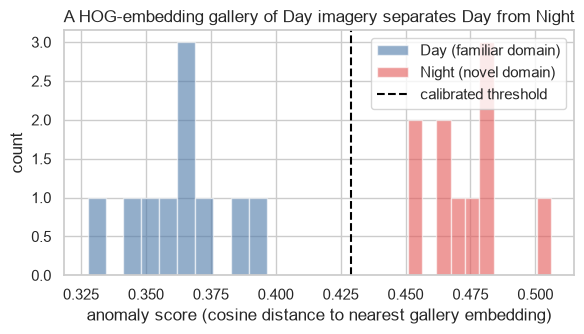

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(day_scores, bins=10, alpha=0.6, label="Day (familiar domain)", color="#4C78A8")
ax.hist(night_scores, bins=10, alpha=0.6, label="Night (novel domain)", color="#E45756")
ax.axvline(threshold, color="black", linestyle="--", label="calibrated threshold")
ax.set_xlabel("anomaly score (cosine distance to nearest gallery embedding)")
ax.set_ylabel("count")
ax.legend()
ax.set_title("A HOG-embedding gallery of Day imagery separates Day from Night")
plt.tight_layout()
plt.show()

## Takeaway

The anomaly scorer is deliberately *not* a replacement for the class-based detectors --
it has no notion of "drone" or "vehicle," only "unlike the reference gallery." Read a high
anomaly score as "worth a human glance because it's visually unusual," not as a threat
classification; see `docs/USER_MANUAL.md` and `docs/ARCHITECTURE.md` for how this
complements, rather than replaces, the four-class taxonomy.